<h1>PARTE 2: Bosque</h1>

In [2]:
import pandas as pd
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

<h2> 1-Tratamiento base</h2>


In [3]:
df=pd.read_csv("C:\\Users\\fatan\\Downloads\\data_regression_health.csv")
df[:10]
##Nuestra variable objetivo es predecir Health_Score

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
0,45.960570,31.996777,5,55.403270,7.300359,0,2.834707,70.542122
1,38.340828,29.623168,6,41.838357,7.012419,1,7.199517,57.244637
2,47.772262,25.298152,5,76.904948,6.028641,1,4.097944,96.333722
3,58.276358,21.765316,2,49.756767,5.802714,1,3.649377,61.321783
4,37.190160,28.491117,2,44.218737,7.912548,0,2.839795,67.175894
5,37.190357,26.967427,2,89.124837,7.786489,1,1.593758,100.000000
6,58.950554,29.475966,5,81.522693,7.085705,0,3.622786,91.385675
7,49.209217,28.175859,3,65.002425,8.386293,0,0.235395,94.853895
8,34.366307,30.247764,4,67.989301,4.058009,1,0.327432,78.356157
9,46.510721,22.323824,4,33.889837,6.153408,0,5.024877,64.380280


<h5> Nulos & Na</h5>

In [4]:
#NULOS
pd.isnull(df).sum() 

Age                    0
BMI                    0
Exercise_Frequency     0
Diet_Quality           0
Sleep_Hours            0
Smoking_Status         0
Alcohol_Consumption    0
Health_Score           0
dtype: int64

In [5]:
#NA
df.isna().sum()

Age                    0
BMI                    0
Exercise_Frequency     0
Diet_Quality           0
Sleep_Hours            0
Smoking_Status         0
Alcohol_Consumption    0
Health_Score           0
dtype: int64

<h5> Variables</h5>

In [6]:
#Conteos
for col in df.columns:
    print(f'\n📊 Variable: {col}')
    display(pd.concat(
        [df[col].value_counts(), df[col].value_counts(1)],
        axis=1,
        keys=['Conteo', 'Proporción']
    ))


📊 Variable: Age


,Conteo,Proporción
45.960570,1,0.001
15.119317,1,0.001
42.377017,1,0.001
38.267675,1,0.001
33.116056,1,0.001
...,...,...
44.955177,1,0.001
33.235305,1,0.001
30.133355,1,0.001
42.924247,1,0.001



📊 Variable: BMI


,Conteo,Proporción
31.996777,1,0.001
23.165878,1,0.001
19.967287,1,0.001
30.699393,1,0.001
31.585575,1,0.001
...,...,...
23.059116,1,0.001
25.852081,1,0.001
25.802870,1,0.001
25.015230,1,0.001



📊 Variable: Exercise_Frequency


...

,Conteo,Proporción
0,501,0.501
1,499,0.499



📊 Variable: Alcohol_Consumption


,Conteo,Proporción
2.834707,1,0.001
3.978108,1,0.001
3.775197,1,0.001
1.346271,1,0.001
6.608569,1,0.001
...,...,...
3.011483,1,0.001
4.605562,1,0.001
4.291558,1,0.001
3.507458,1,0.001



📊 Variable: Health_Score


,Conteo,Proporción
100.000000,242,0.242
70.542122,1,0.001
68.625766,1,0.001
83.950901,1,0.001
85.939618,1,0.001
...,...,...
71.200686,1,0.001
75.874576,1,0.001
91.167406,1,0.001
48.158023,1,0.001


In [7]:
df.dtypes 

Age                    float64
BMI                    float64
Exercise_Frequency       int64
Diet_Quality           float64
Sleep_Hours            float64
Smoking_Status           int64
Alcohol_Consumption    float64
Health_Score           float64
dtype: object

<p>Los cambios realizados a las variables tienen como objetivos principales la <strong>categorización</strong>, la mejora en la <strong>visualización</strong> y el <strong>ahorro de memoria</strong>. Entre estos cambios se incluyen:</p>
<ul>
  <li>Conversión de la variable <strong>Age</strong> de tipo <em>float</em> a tipo <em>entero</em>.</li>
  <li>Transformación de las variables <strong>Exercise_Frequency</strong> y <strong>Smoking_Status</strong> de tipo <em>int</em> a tipo <em>string</em>, ya que representan categorías discretas.</li>
  <li>Con la excepción de <strong>BMI</strong> —que se categorizará en rangos basados en las recomendaciones de la OMS— al igual que las horas de sueño, las demás variables de tipo <em>float</em> serán redondeadas a <strong>3 decimales</strong> para facilitar su manejo.</li>
</ul>


In [4]:
#Types> Change

df['Age'] = df['Age'].astype(int)


var2 = ['Smoking_Status', 'Exercise_Frequency']
for i in var2:
    df[i] = df[i].astype('str')


column_round = ["Alcohol_Consumption", "Diet_Quality"]
df[column_round] = df[column_round].round(2)


In [5]:
df['BMI_Category'] = np.where(df['BMI'] < 18.5, 'Bajo peso',
                          np.where(df['BMI'] < 25, 'Normal',
                          np.where(df['BMI'] < 30, 'Sobrepeso',
                                   'Obesidad')))

In [6]:
df['Sleep_Hours'] = pd.to_numeric(df['Sleep_Hours'])
df['Sleep_Quality'] = np.where(df['Sleep_Hours'].between(7, 9), 'Adecuado',
                            np.where(df['Sleep_Hours'].isin([6, 10]), 'Marginal',
                            'Inadecuado'))

In [11]:
df

,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score,BMI_Category,Sleep_Quality
0,45,31.996777,5,55.40,7.300359,0,2.83,70.542122,Obesidad,Adecuado
1,38,29.623168,6,41.84,7.012419,1,7.20,57.244637,Sobrepeso,Adecuado
2,47,25.298152,5,76.90,6.028641,1,4.10,96.333722,Sobrepeso,Inadecuado
3,58,21.765316,2,49.76,5.802714,1,3.65,61.321783,Normal,Inadecuado
4,37,28.491117,2,44.22,7.912548,0,2.84,67.175894,Sobrepeso,Adecuado
...,...,...,...,...,...,...,...,...,...,...
995,36,30.350751,1,60.67,8.470913,0,3.82,67.993747,Obesidad,Adecuado
996,61,24.867394,3,66.53,5.355398,1,5.60,72.377621,Normal,Inadecuado
997,47,20.590627,4,69.82,8.641864,0,8.20,100.000000,Normal,Adecuado
998,33,24.184665,6,70.72,7.941557,0,3.68,100.000000,Normal,Adecuado


In [12]:
df.dtypes

Age                      int32
BMI                    float64
Exercise_Frequency      object
Diet_Quality           float64
Sleep_Hours            float64
Smoking_Status          object
Alcohol_Consumption    float64
Health_Score           float64
BMI_Category            object
Sleep_Quality           object
dtype: object

In [13]:
for col in df.columns:
    print(f"--- {col} ---")
    print(df[col].describe())
    print("\n")

--- Age ---
count    1000.000000
mean       39.742000
std        11.751491
min         1.000000
25%        32.000000
50%        40.000000
75%        47.000000
max        86.000000
Name: Age, dtype: float64


--- BMI ---
count    1000.000000
mean       25.354181
std         4.987272
min        10.298057
25%        21.968792
50%        25.315386
75%        28.644411
max        40.965538
Name: BMI, dtype: float64


--- Exercise_Frequency ---
count     1000
unique       7
top          0
freq       161
Name: Exercise_Frequency, dtype: object


--- Diet_Quality ---
count    1000.00000
mean       69.95300
std        14.97206
min        19.91000
25%        59.94500
50%        69.97500
75%        80.53000
max       110.27000
Name: Diet_Quality, dtype: float64


--- Sleep_Hours ---
count    1000.000000
mean        6.973135
std         1.517218
min         2.431107
25%         5.903351
50%         6.990847
75%         8.054595
max        11.638962
Name: Sleep_Hours, dtype: float64


--- Smoking_S

In [7]:
#Nos quedamos con dosis positivas 
df= df[df['Alcohol_Consumption'] >= 0]

In [8]:
df.dtypes 

Age                      int32
BMI                    float64
Exercise_Frequency      object
Diet_Quality           float64
Sleep_Hours            float64
Smoking_Status          object
Alcohol_Consumption    float64
Health_Score           float64
BMI_Category            object
Sleep_Quality           object
dtype: object

In [9]:
col_num = [x for x in df.columns if df.dtypes[x]!='O']
col_num

col_cat= [x for x in df.columns if df.dtypes[x]=='O']
col_cat

['Exercise_Frequency', 'Smoking_Status', 'BMI_Category', 'Sleep_Quality']

<h2>2-Analisis bivariado</h2>

<h5>Correlaciones</h5>

In [17]:
df[col_num].corr()

,Age,BMI,Diet_Quality,Sleep_Hours,Alcohol_Consumption,Health_Score
Age,1.000000,-0.033287,-0.011182,0.022648,-0.063058,-0.184415
BMI,-0.033287,1.000000,-0.049029,0.035908,-0.002818,-0.420390
Diet_Quality,-0.011182,-0.049029,1.000000,0.003359,0.007230,0.689047
Sleep_Hours,0.022648,0.035908,0.003359,1.000000,-0.010661,0.266081
Alcohol_Consumption,-0.063058,-0.002818,0.007230,-0.010661,1.000000,-0.101544
Health_Score,-0.184415,-0.420390,0.689047,0.266081,-0.101544,1.000000


<ul>
  <li><strong>Age (-0.184):</strong> Hay una correlación negativa débil-moderada con <em>Health_Score</em>, lo que indica que conforme aumenta la edad, el puntaje de salud tiende a bajar ligeramente.</li>
  <li><strong>BMI (-0.420):</strong> Correlación negativa moderada. Un BMI más alto (que puede indicar sobrepeso u obesidad) está asociado con un menor <em>Health_Score</em>, es decir, peor salud.</li>
  <li><strong>Diet_Quality (0.689):</strong> Correlación positiva fuerte. Mejor calidad de dieta se asocia con un mejor puntaje de salud.</li>
  <li><strong>Sleep_Hours (0.266):</strong> Correlación positiva moderada. Más horas de sueño se relacionan con mejor <em>Health_Score</em>.</li>
  <li><strong>Alcohol_Consumption (-0.101):</strong> Correlación negativa débil. Mayor consumo de alcohol puede estar ligeramente asociado con peor salud, pero la relación es débil.</li>
</ul>


<h5>Kendall and Spearman</h5>

In [18]:
display(df[col_num].corr(method='kendall'))
df[col_num].corr(method='spearman')

,Age,BMI,Diet_Quality,Sleep_Hours,Alcohol_Consumption,Health_Score
Age,1.000000,-0.040265,-0.009568,0.033272,-0.038774,-0.110130
BMI,-0.040265,1.000000,-0.033171,0.032003,-0.005736,-0.288406
Diet_Quality,-0.009568,-0.033171,1.000000,0.000486,0.003366,0.512196
Sleep_Hours,0.033272,0.032003,0.000486,1.000000,-0.008460,0.161846
Alcohol_Consumption,-0.038774,-0.005736,0.003366,-0.008460,1.000000,-0.070765
Health_Score,-0.110130,-0.288406,0.512196,0.161846,-0.070765,1.000000


,Age,BMI,Diet_Quality,Sleep_Hours,Alcohol_Consumption,Health_Score
Age,1.000000,-0.058140,-0.014151,0.047761,-0.058381,-0.160023
BMI,-0.058140,1.000000,-0.050109,0.046516,-0.008542,-0.413834
Diet_Quality,-0.014151,-0.050109,1.000000,0.001279,0.004903,0.696103
Sleep_Hours,0.047761,0.046516,0.001279,1.000000,-0.011651,0.235548
Alcohol_Consumption,-0.058381,-0.008542,0.004903,-0.011651,1.000000,-0.104023
Health_Score,-0.160023,-0.413834,0.696103,0.235548,-0.104023,1.000000


<h5>Graficos</h5>

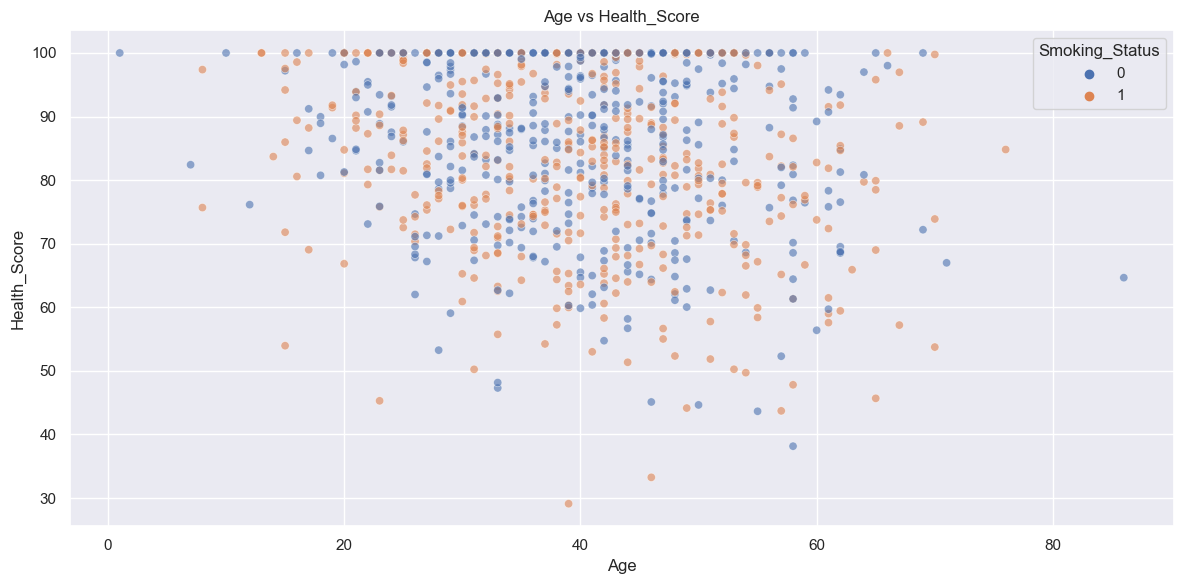

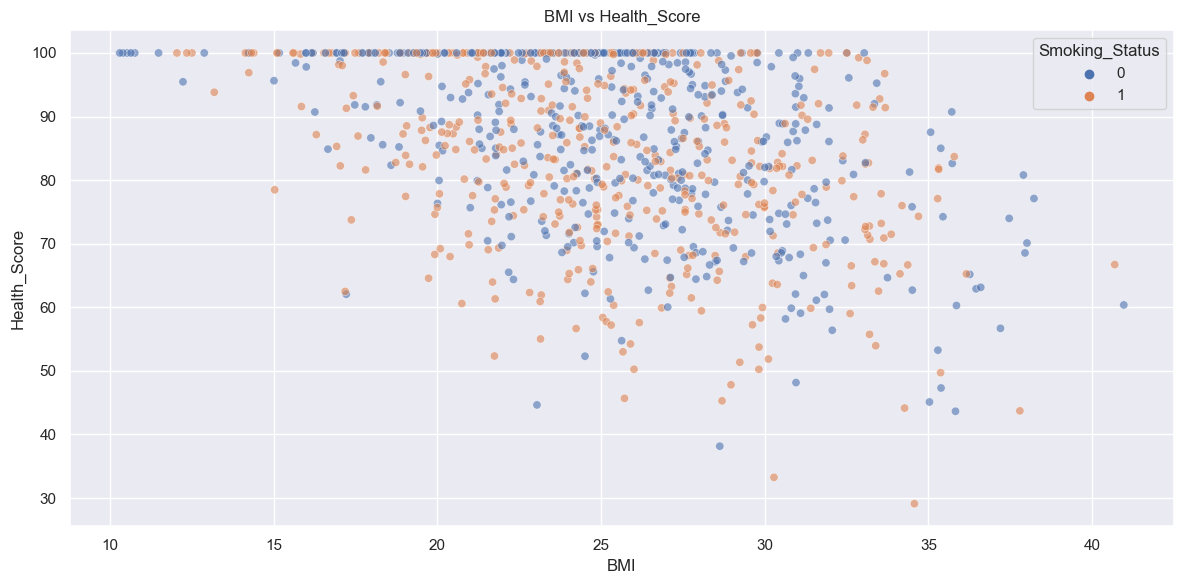

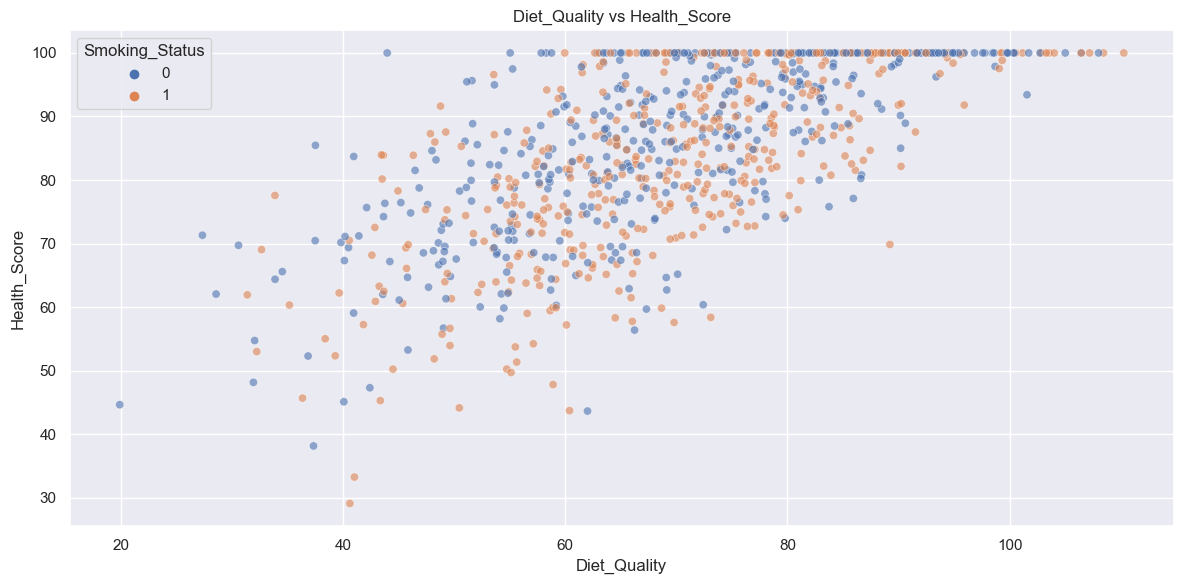

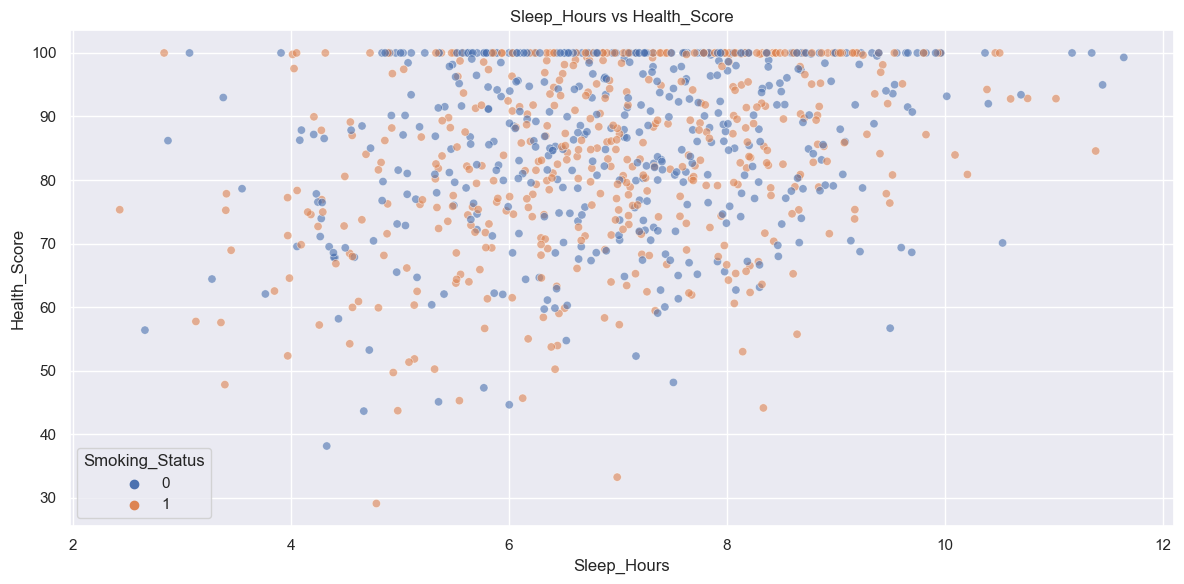

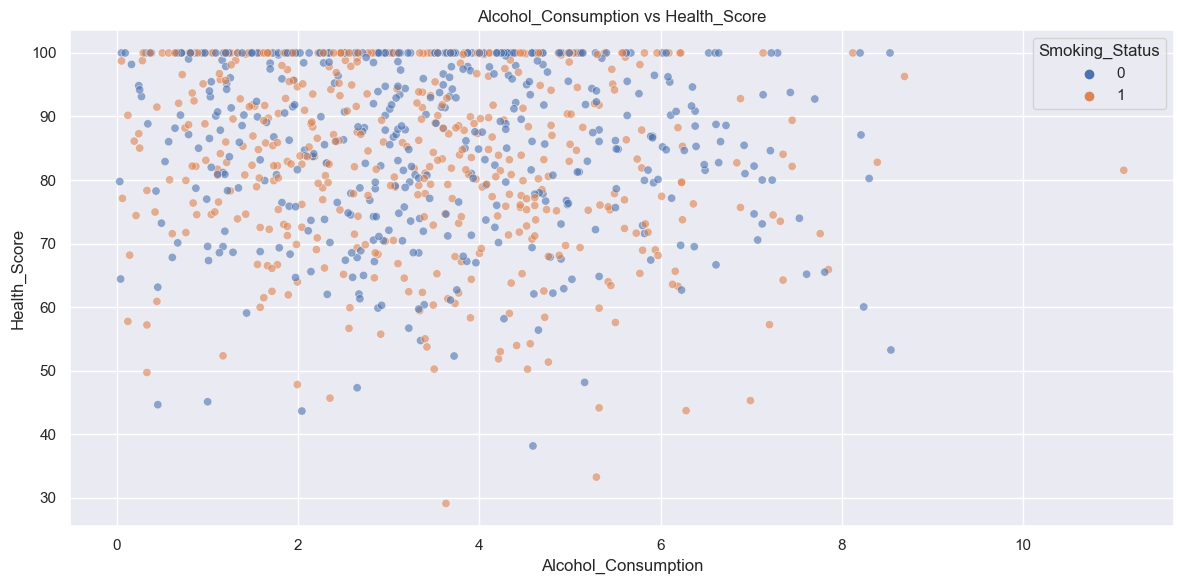

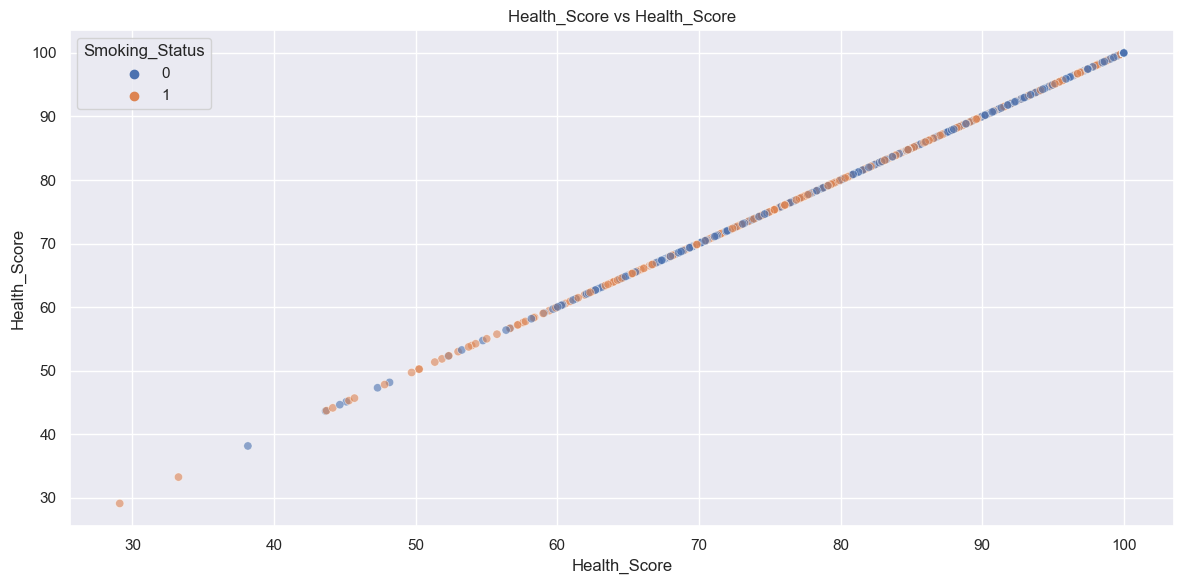

In [19]:
 for col in col_num:
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x=col, y='Health_Score', hue='Smoking_Status', alpha=0.6)
    plt.title(f'{col} vs Health_Score')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

<h5>Anova</h5>

In [20]:
from statsmodels import api as ap
from statsmodels.formula.api import ols


print("# Resultados ANOVA para variables categóricas respecto a Health_Score\n")

for col in col_cat:
    print(f"## Variable: {col}\n")
    formula = f'Health_Score ~ C({col})'  # Marca variable categórica
    modelo = ols(formula, data=df).fit()
    anova = ap.stats.anova_lm(modelo)
    print(anova.to_markdown())
    print("\n---\n")

# Resultados ANOVA para variables categóricas respecto a Health_Score

## Variable: Exercise_Frequency

|                       |   df |   sum_sq |   mean_sq |         F |        PR(>F) |
|:----------------------|-----:|---------:|----------:|----------:|--------------:|
| C(Exercise_Frequency) |    6 |  10077.1 |  1679.51  |   9.30028 |   6.42757e-10 |
| Residual              |  923 | 166682   |   180.587 | nan       | nan           |

---

## Variable: Smoking_Status

|                   |   df |    sum_sq |   mean_sq |        F |       PR(>F) |
|:------------------|-----:|----------:|----------:|---------:|-------------:|
| C(Smoking_Status) |    1 |   1930.35 |  1930.35  |  10.2464 |   0.00141608 |
| Residual          |  928 | 174829    |   188.393 | nan      | nan          |

---

## Variable: BMI_Category

|                 |   df |   sum_sq |   mean_sq |        F |        PR(>F) |
|:----------------|-----:|---------:|----------:|---------:|--------------:|
| C(BMI_Category) |   

<h5>Resultados ANOVA - Health_Score por Variables Categóricas</h5>
<ul>
  <li><strong>Exercise_Frequency:</strong> Efecto significativo (<em>F</em> = 9.30, <em>p</em> &lt; 0.001). La frecuencia de ejercicio influye de manera significativa en el puntaje de salud.</li>
  <li><strong>Smoking_Status:</strong> Efecto significativo (<em>F</em> = 10.25, <em>p</em> = 0.0014). El estatus de fumador tiene un impacto relevante sobre el Health_Score.</li>
  <li><strong>BMI_Category:</strong> Efecto altamente significativo (<em>F</em> = 53.99, <em>p</em> &lt; 0.0001). Los distintos rangos de IMC tienen una fuerte relación con el puntaje de salud.</li>
  <li><strong>Sleep_Quality:</strong> Efecto significativo (<em>F</em> = 7.64, <em>p</em> = 0.0058). La calidad del sueño también está relacionada de forma significativa con el Health_Score.</li>
</ul>




<h5>+ Graficos(Apoyo)</h5>

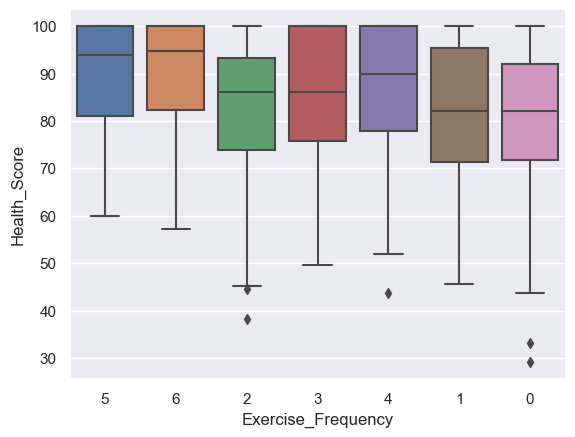

In [21]:
sns.boxplot(data = df, x= 'Exercise_Frequency', y = 'Health_Score')
plt.show()

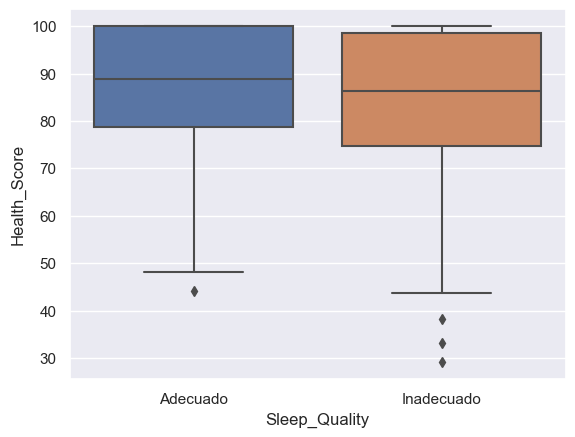

In [23]:
sns.boxplot(data = df, x= 'Sleep_Quality', y = 'Health_Score')
plt.show()

<p>
En el análisis destaca una fuerte influencia de <strong>Diet_Quality</strong> en el modelo, así como una participación moderada de <strong>BMI</strong>, <strong>frecuencia de ejercicio</strong>, las <strong>horas de sueño</strong> y el <strong>consumo de alcohol</strong>. A partir del gráfico, se observa que la <strong>edad</strong> no parece estar tan relacionada con el <strong>Health Score</strong> en comparación con otras variables. No obstante, el modelo se correrá considerando dicha variable.
</p>



<h2>3-Bosque</h2>

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

<h5>Dummies</h5>

In [11]:
df_dumm=df.copy()
df_dumm = pd.get_dummies(df.drop(columns = ['Health_Score','BMI', 'Sleep_Hours']), 
                          drop_first=True) 

In [12]:
df_dumm

,Age,Diet_Quality,Alcohol_Consumption,Exercise_Frequency_1,Exercise_Frequency_2,Exercise_Frequency_3,Exercise_Frequency_4,Exercise_Frequency_5,Exercise_Frequency_6,Smoking_Status_1,BMI_Category_Normal,BMI_Category_Obesidad,BMI_Category_Sobrepeso,Sleep_Quality_Inadecuado
0,45,55.40,2.83,0,0,0,0,1,0,0,0,1,0,0
1,38,41.84,7.20,0,0,0,0,0,1,1,0,0,1,0
2,47,76.90,4.10,0,0,0,0,1,0,1,0,0,1,1
3,58,49.76,3.65,0,1,0,0,0,0,1,1,0,0,1
4,37,44.22,2.84,0,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,36,60.67,3.82,1,0,0,0,0,0,0,0,1,0,0
996,61,66.53,5.60,0,0,1,0,0,0,1,1,0,0,1
997,47,69.82,8.20,0,0,0,1,0,0,0,1,0,0,0
998,33,70.72,3.68,0,0,0,0,0,1,0,1,0,0,0


<h5>Entrenamiento</h5>

In [110]:
x_ent, x_val, y_ent, y_val = train_test_split(df_dumm, df.Health_Score,
                                              train_size=0.8,
                                              random_state=30
                                             )

In [78]:
x_ent.shape #Si tomamos 4 del max feature: Combinacion de las 22 variables tomadas de 4 en 4

(744, 14)

<h5>Objeto</h5>

In [189]:
bosque = RandomForestRegressor( n_estimators=150,
                                criterion='squared_error',
                                max_features='auto',   
                                max_depth=5,
                                bootstrap=True,
                                random_state=40,
                               min_weight_fraction_leaf=0.05,
                               max_samples=0.65
                               )
#Entrenamiento
bosque.fit(x_ent, y_ent)

RandomForestRegressor(max_depth=5, max_samples=0.65,
                      min_weight_fraction_leaf=0.05, n_estimators=150,
                      random_state=40)

<h5>Score</h5>

In [190]:
## Score entrenamiento
print('Score entrenamiento:', bosque.score(x_ent, y_ent))

## Score validación
print('Score validación:', bosque.score(x_val, y_val))

Score entrenamiento: 0.6374714638572803
Score validación: 0.6378780538639102


<h5>Bosque con ayuda de la optimizacion</h5>

In [225]:

bosque3 = RandomForestRegressor( n_estimators=950,
                                criterion='squared_error',
                                max_features= 'auto',   
                                max_depth=6,
                                bootstrap=True,
                                random_state=40,
                               min_weight_fraction_leaf=0.015,
                                min_samples_split=0.02
                               )
#Entrenamiento
bosque3.fit(x_ent, y_ent)
## Score entrenamiento
print('Score entrenamiento:', bosque3.score(x_ent, y_ent))

## Score validación
print('Score validación:', bosque3.score(x_val, y_val))

Score entrenamiento: 0.7412074535244078
Score validación: 0.7026679329344626


<p><strong>Conclusión:</strong><br>
El uso de la optimización de hiperparámetros fue clave para mejorar el desempeño del modelo, elevando el score de validación de <strong>0.638</strong> a <strong>0.703</strong>. Si bien no garantiza el resultado ideal, esta herramienta resulta muy útil para identificar combinaciones de hiper-parámetros que fortalecen la capacidad predictiva y sugieren caminos claros para seguir ajustando y mejorando el modelo.
</p>


<h2>+Extra:Optimización de Hiper-Parámetros </h2>

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [16]:
print(x_ent.shape)
print(x_val.shape)

(744, 14)
(186, 14)


In [17]:
print("Max_features:")
print(x_ent.shape[1]/3)
print(np.sqrt(x_ent.shape[1]))
print(np.log(x_ent.shape[1]), '\n')

Max_features:
4.666666666666667
3.7416573867739413
2.6390573296152584 



In [20]:
from math import factorial

print("Numero de Arboles:")
for k in range(2, 6):
    print(factorial(x_ent.shape[1])/(factorial(x_ent.shape[1]-k)*factorial(k)) )

Numero de Arboles:
91.0
364.0
1001.0
2002.0


In [22]:
print("Profundidad (división 3/4):")
for i in range(7):
    print('Profundidad', i)
    print(x_ent.shape[0] * (3/4)**i)

Profundidad (división 3/4):
Profundidad 0
744.0
Profundidad 1
558.0
Profundidad 2
418.5
Profundidad 3
313.875
Profundidad 4
235.40625
Profundidad 5
176.5546875
Profundidad 6
132.416015625


In [151]:
bosque2 = RandomForestRegressor(criterion = 'squared_error', bootstrap = True, random_state=40)

In [163]:
red = {
    'n_estimators':range(50,1000),
    'max_features': range(2, 6),
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [.02, 0.05, .1, .15],
    'min_weight_fraction_leaf':  [.02, 0.05, .1, .15],
}

In [164]:
metricas = {
    'R2': 'r2',
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error'
}

In [165]:
optimizador = RandomizedSearchCV(bosque2, param_distributions = red, scoring = metricas, n_jobs=-1, cv = 2,
                                 refit = 'MSE', n_iter = 50, verbose = 2)

optimizador.fit(x_ent, y_ent)

Fitting 2 folds for each of 50 candidates, totalling 100 fits


RandomizedSearchCV(cv=2, estimator=RandomForestRegressor(random_state=40),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [2, 3, 4, 5, 6],
                                        'max_features': range(2, 6),
                                        'min_samples_split': [0.02, 0.05, 0.1,
                                                              0.15],
                                        'min_weight_fraction_leaf': [0.02, 0.05,
                                                                     0.1,
                                                                     0.15],
                                        'n_estimators': range(50, 1000)},
                   refit='MSE',
                   scoring={'MAE': 'neg_mean_absolute_error',
                            'MSE': 'neg_mean_squared_error', 'R2': 'r2'},
                   verbose=2)

In [226]:
#SCORES
resultados = pd.DataFrame(optimizador.cv_results_)
cols = [x for x in resultados.columns if (not x.startswith('mean_')) & (not x.startswith('std_')) ]
resultados[cols]

,param_n_estimators,param_min_weight_fraction_leaf,param_min_samples_split,param_max_features,param_max_depth,params,split0_test_R2,split1_test_R2,rank_test_R2,split0_test_MSE,split1_test_MSE,rank_test_MSE,split0_test_MAE,split1_test_MAE,rank_test_MAE
0,947,0.1,0.15,2,4,"{'n_estimators': 947, 'min_weight_fraction_lea...",0.296835,0.290301,45,-126.891460,-144.063467,45,-9.434882,-9.706719,44
1,530,0.1,0.05,2,5,"{'n_estimators': 530, 'min_weight_fraction_lea...",0.301263,0.294745,43,-126.092517,-143.161348,43,-9.406880,-9.675007,43
2,66,0.02,0.05,4,4,"{'n_estimators': 66, 'min_weight_fraction_leaf...",0.487623,0.457973,11,-92.462320,-110.027439,11,-7.919179,-8.434230,11
3,186,0.15,0.1,5,6,"{'n_estimators': 186, 'min_weight_fraction_lea...",0.393160,0.398377,28,-109.508867,-122.124946,28,-8.711496,-8.831469,28
4,421,0.02,0.05,4,6,"{'n_estimators': 421, 'min_weight_fraction_lea...",0.556423,0.550820,2,-80.046872,-91.180062,2,-7.263351,-7.618941,2
5,897,0.1,0.1,4,5,"{'n_estimators': 897, 'min_weight_fraction_lea...",0.434551,0.424389,19,-102.039534,-116.844661,19,-8.385390,-8.638251,19
6,982,0.02,0.1,3,6,"{'n_estimators': 982, 'min_weight_fraction_lea...",0.481005,0.462591,12,-93.656642,-109.089838,12,-8.026111,-8.368290,13
7,834,0.02,0.02,5,6,"{'n_estimators': 834, 'min_weight_fraction_lea...",0.578872,0.594098,1,-75.995697,-82.394950,1,-6.974322,-7.200105,1
8,687,0.02,0.05,5,2,"{'n_estimators': 687, 'min_weight_fraction_lea...",0.398887,0.390969,29,-108.475528,-123.628701,29,-8.720482,-8.958674,29
9,544,0.15,0.05,5,4,"{'n_estimators': 544, 'min_weight_fraction_lea...",0.409170,0.407946,24,-106.619824,-120.182460,24,-8.587995,-8.731366,22


In [167]:
# Mejor modelo
Bosque_Optimo = optimizador.best_estimator_
Bosque_Optimo

RandomForestRegressor(max_depth=6, max_features=5, min_samples_split=0.02,
                      min_weight_fraction_leaf=0.02, n_estimators=834,
                      random_state=40)

In [168]:
## Score entrenamiento
print('Score entrenamiento:', Bosque_Optimo.score(x_ent, y_ent))

## Score validación
print('Score validación:', Bosque_Optimo.score(x_val, y_val))

Score entrenamiento: 0.6924438837929032
Score validación: 0.6549527182147785
